In [109]:
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition # toolNode and toolCondition
from langgraph.checkpoint.memory import InMemorySaver # checkpointers

from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import HumanMessage, BaseMessage

# tool related imports
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults
from dotenv import load_dotenv




In [110]:
"""
Task: 

- Langgraph with tool node

"""

load_dotenv()

True

In [111]:
class ToolsState(TypedDict):
    messages: Annotated[BaseMessage, add_messages]

In [112]:
# creating a tool

# tool - 1
web_search_tool = DuckDuckGoSearchResults()


# tool - 2
@tool
def calculator(firstNumber: int, secondNumber: int, op: Literal['add', 'sub', 'mul', 'div'])->int:
    """
    calculator tool, which takes firstNumber, secondNumber and op and performs necessary action
    """
    if(op == 'add'):
        return firstNumber + secondNumber
    elif(op == 'sub'):
        return firstNumber - secondNumber
    elif(op == 'mul'):
        return firstNumber * secondNumber
    elif(op == 'div'):
        return firstNumber / secondNumber
    else: 
        raise Exception("Invalid op")




In [113]:
tools = [web_search_tool, calculator]

chatModelOld = ChatOpenAI()

chatModel = chatModelOld.bind_tools(tools)

In [114]:
state = StateGraph(ToolsState)



In [115]:
# creating nodes

def chatNode(toolState: ToolsState) -> ToolsState:
    response = chatModel.invoke(toolState['messages'])
    return {'messages': [response]}


toolNode = ToolNode(tools)


In [116]:
state.add_node('chatNode', chatNode)
state.add_node('tools', toolNode) # name of the node should be always tools

state.add_edge(START, 'chatNode')
state.add_conditional_edges('chatNode', tools_condition)
state.add_edge('tools', 'chatNode')


# state.add_edge('chatNode', END) # dont uncomment thisline


In [117]:
checkpointer = InMemorySaver()

In [118]:
CONFIG = {"configurable": {"thread_id": 1}}

workflow = state.compile(checkpointer=checkpointer)

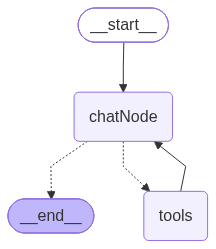

In [119]:
workflow

In [120]:
initialState = {
    'messages':[HumanMessage('hi')]
}

reponse1 = workflow.invoke(initialState, config=CONFIG)

In [121]:
reponse1

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='ee21beb0-7a94-4f27-a836-751425ef1fef'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 132, 'total_tokens': 142, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EEt7SDGYUWA9QKYbQqz8BUd3FyBw4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01e71-ec63-7901-95d9-3a576de88630-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 132, 'output_tokens': 10, 'total_tokens': 142, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'out

In [128]:
initialState = {
    'messages':[HumanMessage('what is the capital of indian and multiply its temperature with 100')]
}

reponse1 = workflow.stream(initialState, config=CONFIG, stream_mode='updates')

for response in reponse1:
    print(response)

{'chatNode': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 2296, 'total_tokens': 2316, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EEtDHINGh8IUBnVAlBaLSa8hVPvkh', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01e77-6d1a-72f2-b798-c27d8d60f7b0-0', tool_calls=[{'name': 'duckduckgo_results_json', 'args': {'query': 'capital of India'}, 'id': 'call_QRQgKM6j3Cp5VELZ8CLFCMnU', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2296, 'output_tokens': 20, 'total_tokens': 2316, 'input_token_details': {'audio': 0, 'cache_read': 0}